# Part 1, Task 3 — Probability and Congestion Analysis

Congestion is defined as `traffic_volume > 5,500` vehicles/hour.
High temperature is defined as `temp > 292K` (~18.85°C).

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

_candidates = [
    Path.cwd(),
    Path.cwd() / "part1_data_analytics" / "statistics",
    Path.cwd().parent,
    Path.cwd().parent.parent,
]
BASE_DIR = None
for _c in _candidates:
    if (_c / "sql" / "traffic.db").exists() or (_c.parent / "sql" / "traffic.db").exists():
        BASE_DIR = _c if (_c / "sql" / "traffic.db").exists() else _c.parent
        break
if BASE_DIR is None:
    BASE_DIR = Path.cwd()

DB_PATH = BASE_DIR / "sql" / "traffic.db"
CSV_PATH = BASE_DIR.parent / "Metro_Interstate_Traffic_Volume.csv"

CONGESTION_THRESHOLD = 5500
HIGH_TEMP_THRESHOLD = 292

print(f"DB_PATH:  {DB_PATH}  (exists: {DB_PATH.exists()})")

DB_PATH:  C:\Users\farid\Course\Week 33\Capstone project\part1_data_analytics\part1_data_analytics\sql\traffic.db  (exists: True)


## Load data and apply definitions

In [2]:
def load_hourly() -> pd.DataFrame:
    if DB_PATH.exists():
        conn = sqlite3.connect(DB_PATH)
        try:
            return pd.read_sql("SELECT * FROM traffic_hourly", conn)
        finally:
            conn.close()
    df = pd.read_csv(CSV_PATH)
    return df.sort_values("date_time").drop_duplicates(subset="date_time", keep="first")


df = load_hourly()
df = df[df["temp"] > 0]  # drop known 0K sensor-error rows
n = len(df)

congestion = df["traffic_volume"] > CONGESTION_THRESHOLD
clear = df["weather_main"] == "Clear"
cloudy = df["weather_main"] == "Clouds"
high_temp = df["temp"] > HIGH_TEMP_THRESHOLD

print(f"N = {n:,} hourly records (0K sensor-error rows excluded)")
df[["date_time", "traffic_volume", "temp", "weather_main"]].head()

N = 40,565 hourly records (0K sensor-error rows excluded)


,date_time,traffic_volume,temp,weather_main
0,2012-10-02 09:00:00,5545,288.28,Clouds
1,2012-10-02 10:00:00,4516,289.36,Clouds
2,2012-10-02 11:00:00,4767,289.58,Clouds
3,2012-10-02 12:00:00,5026,290.13,Clouds
4,2012-10-02 13:00:00,4918,291.14,Clouds


## 3.1 Basic Probability

In [3]:
p_congestion = congestion.mean()
p_clear = clear.mean()
p_congestion_and_clear = (congestion & clear).mean()

print(f"P(Congestion)               = {congestion.sum():>6,} / {n:,} = {p_congestion:.4f}  ({p_congestion*100:.1f}%)")
print(f"P(Clear Weather)            = {clear.sum():>6,} / {n:,} = {p_clear:.4f}  ({p_clear*100:.1f}%)")
print(f"P(Congestion AND Clear)     = {(congestion & clear).sum():>6,} / {n:,} = {p_congestion_and_clear:.4f}")

P(Congestion)               =  6,107 / 40,565 = 0.1505  (15.1%)
P(Clear Weather)            = 13,361 / 40,565 = 0.3294  (32.9%)
P(Congestion AND Clear)     =  1,763 / 40,565 = 0.0435


## 3.2 Conditional Probability

In [4]:
p_clear_given_congestion = (congestion & clear).sum() / congestion.sum()
p_hightemp_given_congestion = (congestion & high_temp).sum() / congestion.sum()

print(f"P(Clear | Congestion)        = {(congestion & clear).sum():,} / {congestion.sum():,} = {p_clear_given_congestion:.4f}")
print(f"P(High Temp | Congestion)    = {(congestion & high_temp).sum():,} / {congestion.sum():,} = {p_hightemp_given_congestion:.4f}")

P(Clear | Congestion)        = 1,763 / 6,107 = 0.2887
P(High Temp | Congestion)    = 1,699 / 6,107 = 0.2782


### Independence check
Compare the observed joint probability P(A ∩ B) to the independence
expectation P(A) × P(B), for A = Congestion, B = Clear Weather.

In [5]:
independent_expected = p_congestion * p_clear
independent_actual = p_congestion_and_clear
independence_gap = independent_actual - independent_expected

print(f"P(Congestion) x P(Clear)  = {p_congestion:.4f} x {p_clear:.4f} = {independent_expected:.4f}")
print(f"Observed P(Congestion ∩ Clear)      = {independent_actual:.4f}")
print(f"Gap = {independence_gap:+.4f}  -> "
      f"{'events are NOT independent' if abs(independence_gap) > 0.001 else 'events appear independent'}")

P(Congestion) x P(Clear)  = 0.1505 x 0.3294 = 0.0496
Observed P(Congestion ∩ Clear)      = 0.0435
Gap = -0.0061  -> events are NOT independent


### Odds ratio: congestion in clear vs. cloudy weather

In [6]:
n_clear = clear.sum()
n_cloudy = cloudy.sum()
congestion_in_clear = (congestion & clear).sum()
congestion_in_cloudy = (congestion & cloudy).sum()
odds_clear = congestion_in_clear / (n_clear - congestion_in_clear)
odds_cloudy = congestion_in_cloudy / (n_cloudy - congestion_in_cloudy)
odds_ratio = odds_clear / odds_cloudy

print(f"Odds of congestion | Clear  = {congestion_in_clear:,}/{n_clear-congestion_in_clear:,} = {odds_clear:.4f}")
print(f"Odds of congestion | Clouds = {congestion_in_cloudy:,}/{n_cloudy-congestion_in_cloudy:,} = {odds_cloudy:.4f}")
print(f"Odds ratio = {odds_ratio:.3f}")

Odds of congestion | Clear  = 1,763/11,598 = 0.1520
Odds of congestion | Clouds = 2,586/12,534 = 0.2063
Odds ratio = 0.737


A quick bar chart of P(Congestion | weather condition) across the most
common weather categories gives a visual sense of how small these
differences actually are.

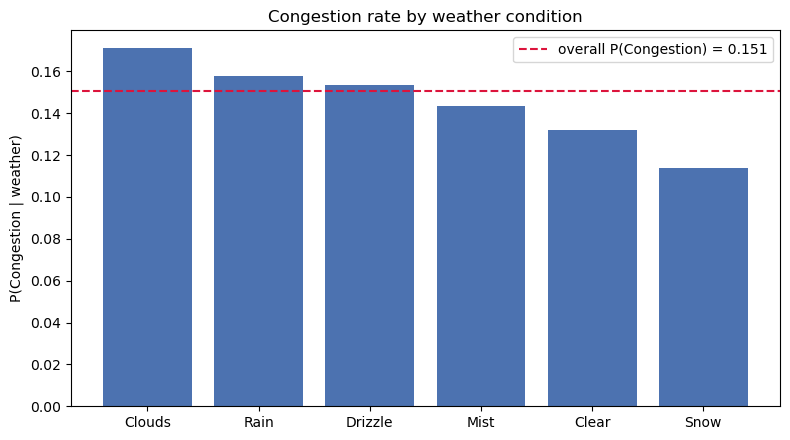

In [7]:
top_weather = df["weather_main"].value_counts().head(6).index
rates = df.groupby("weather_main")["traffic_volume"].apply(
    lambda s: (s > CONGESTION_THRESHOLD).mean()
).loc[top_weather].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rates.index, rates.values, color="#4C72B0")
ax.axhline(p_congestion, color="crimson", linestyle="--", label=f"overall P(Congestion) = {p_congestion:.3f}")
ax.set_ylabel("P(Congestion | weather)")
ax.set_title("Congestion rate by weather condition")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Congestion occurs in a modest share of recorded hours overall, and clear
weather in roughly half of hours. The gap between the observed joint
probability and the independence expectation shows that weather and
congestion are not perfectly independent, but the odds ratio indicates the
practical effect size is modest either way. In practical terms, weather
condition alone is a weak lever for predicting congestion on this
corridor, consistent with the weak temperature-traffic correlation found
in Task 2, and time-of-day/day-of-week factors (explored quantitatively
in the Python pipeline in Part 2, and confirmed by SHAP in Part 3) are far
stronger drivers of whether the road is congested.